<a href="https://colab.research.google.com/github/NguyenThien1906/Image-Video-Processing/blob/main/src/CSPDarknet53.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is the implementation of CSPDarknet53 on CPU & GPU.

In [ ]:
!uv pip install -q --system numba-cuda==0.4.0
from numba import config
config.CUDA_ENABLE_PYNVJITLINK = 1

# Architecture

Darknet53:


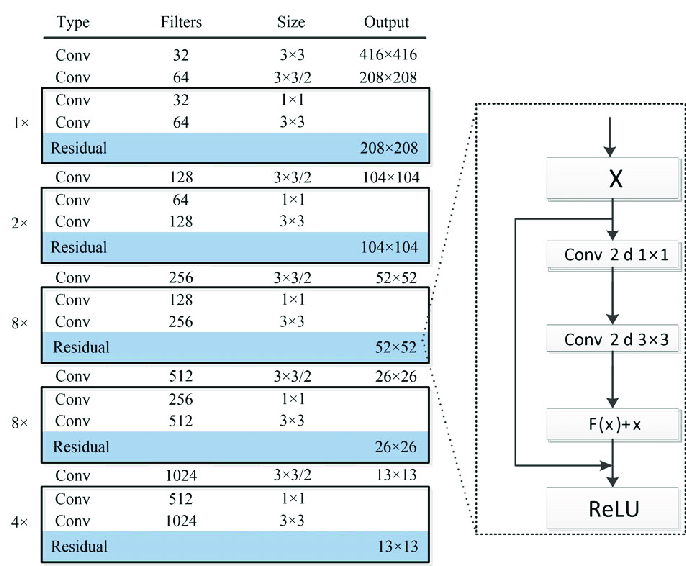

# CPU Implementation: Darknet53

## Step-by-step implementation

For testing, let's give this input of images sized (5, 3, 5, 5), meaning
1. No. of images is 5.
2. Image size is 3 x 5 x 5. ($C_{in} \times W \times H$).

Kernel size should be $K \times K$ with corresponding padding and parameters, which we apply the same 2D kernel for the entire 3D image so the 3D size is $C_{in} \times K \times K$, with a bias. Therefore, in a convolution, we need to store $C_{out} \times K \times K$ weights and $C_{out}$ biases.


In [ ]:
import numpy as np
input = np.random.randn(5, 3, 5, 5)
kernel = np.random.randn(10, 3, 3)
bias = np.full(10, 0, dtype=np.float64)
print(input.dtype, kernel.dtype, bias.dtype)

float64 float64 float64


In [ ]:
print(kernel, np.repeat(kernel[:, np.newaxis, :, :], 3, axis=1))

[[[ 1.10103925 -0.12972216 -1.22070485]
  [ 0.1470502   0.72034768  0.00951953]
  [-0.46735264 -0.59656149  1.02146853]]

 [[-1.26632027  0.02275083 -0.53646523]
  [ 0.3869789  -2.04827887  0.19962276]
  [ 1.04478198 -0.50599035 -0.57672849]]

 [[ 0.54257155  0.71574076  1.81060788]
  [-0.3714911   0.12236639  0.95502673]
  [ 0.13395185  0.77450943  0.15560108]]

 [[-0.46028734 -0.74388344 -2.47590537]
  [-0.86182683  1.18929334  1.13378873]
  [-0.29393662 -0.36596207 -0.42971623]]

 [[ 0.99136701  1.97124334  0.58841273]
  [ 0.26268402  0.12229534 -0.18612069]
  [ 0.84299828 -1.12547219  0.78062618]]

 [[-1.48405004 -0.08440174  2.27972122]
  [-0.08561179  0.2006991   0.888483  ]
  [ 0.21623822 -0.58534161  1.90436967]]

 [[-0.48950831 -0.52247354  0.32163118]
  [ 0.54484239  1.19983976  0.01810371]
  [ 0.46788335  2.10475862 -0.85847097]]

 [[-0.62006596  0.48971109 -1.64710767]
  [ 1.4686014   1.13189907 -0.31032982]
  [-0.08055938 -0.93016374  0.92389388]]

 [[-0.25144809 -1.036220

The convolution layer in a CNN shall include 3 steps:
1. Convolution with a 2D kernel.
2. Batch normalization.
3. Leaky ReLU.

In [ ]:
from numba import jit

@jit
def trunc(val, min, max):
  if val < min:
    return min
  elif val > max:
    return max
  else:
    return val

import math
@jit
def conv2d_cpu(input, kernel, bias, output, stride=1, padding=1, dilation=1):
  # calculate
  output_shape = (input.shape[0], kernel.shape[0],
                  math.floor((input.shape[2] - (kernel.shape[1] - 1) * dilation + 2*padding - 1) / stride) + 1,
                  math.floor((input.shape[3] - (kernel.shape[2] - 1) * dilation + 2*padding - 1) / stride) + 1)

  for im in range(output_shape[0]):
    for c_out in range(output_shape[1]):
      for x in range(output_shape[2]):
        for y in range(output_shape[3]):
          sum = 0
          for x_k in range(kernel.shape[1]):
            for y_k in range(kernel.shape[2]):
              x_in = x * stride + x_k * dilation - padding
              y_in = y * stride + y_k * dilation - padding
              x_in = trunc(x_in, 0, input.shape[2] - 1)
              y_in = trunc(y_in, 0, input.shape[3] - 1)

              sum += np.sum(input[im, :, x_in, y_in]) * kernel[c_out, x_k, y_k]
          output[im, c_out, x, y] = sum + bias[c_out]

Test with Torch

In [ ]:
# paras
stride = 1
padding = 1
dilation = 1

# Torch
import torch
import torch.nn.functional as F
import torch.nn as nn
import math
image_tensor = torch.tensor(input)
kernel_tensor = torch.tensor(np.repeat(kernel[:, np.newaxis, :, :], 3, axis=1))
bias_tensor = torch.tensor(bias)
image_tensor = F.pad(image_tensor, (1, 1, 1, 1), mode='replicate')
output_tensor = F.conv2d(image_tensor, kernel_tensor, bias_tensor, stride, 0, dilation)

# Ours
output_shape = (input.shape[0], kernel.shape[0],
                  math.floor((input.shape[2] - (kernel.shape[1] - 1) * dilation + 2*padding - 1) / stride) + 1,
                  math.floor((input.shape[3] - (kernel.shape[2] - 1) * dilation + 2*padding - 1) / stride) + 1)
output = np.full(output_shape, fill_value=0.0, dtype=np.float32)
conv2d_cpu(input, kernel, bias, output, stride, padding, dilation)

print(output_tensor.shape, output.shape)
print(np.allclose(output_tensor.detach().numpy(), output))
print(output_tensor.detach().numpy(), output, sep = '\n')

torch.Size([5, 10, 5, 5]) (5, 10, 5, 5)
True
[[[[-8.44024542e-01  2.06094627e+00 -1.71240910e+00 -8.32416180e+00
    -2.55455467e+00]
   [ 2.43246386e+00  8.04567025e-01 -1.59342773e+00 -1.34289046e+00
    -4.24556937e+00]
   [ 1.57031491e+00 -1.42389984e+00 -5.67898463e+00  7.90451722e+00
     9.23225639e+00]
   [ 2.94442918e+00 -1.04793900e+00 -3.36323903e-01  5.88664042e-01
     5.44859255e-02]
   [ 2.22358697e+00  1.44192202e+00  2.63823562e+00  3.52001551e+00
     1.25379773e+00]]

  [[ 2.73334601e+00  5.22936427e+00 -1.62355297e+00  2.68087687e+00
     6.05887508e+00]
   [ 5.55010033e-02  5.17097213e+00 -3.36110878e+00 -2.90827003e+00
     1.11960465e+01]
   [ 1.72479563e+00  9.23489119e-01 -1.09184307e-02  1.33998331e+00
     2.14098496e+00]
   [-2.67122730e+00 -7.23715934e-01 -2.06392441e+00 -3.22665536e-01
     1.84856491e+00]
   [-2.09707089e+00 -4.98417247e+00 -4.85390064e-01 -4.33633141e+00
     1.81071010e+00]]

  [[-5.51375628e+00 -4.80221304e+00  2.43149949e+00  2.635944

Batch normalization here follows https://www.geeksforgeeks.org/deep-learning/what-is-batch-normalization-in-deep-learning/.

So here are the implementation steps:
1. Calculate variance and mean.
2. Pass through the function.

In [ ]:
from numba import jit
import numpy as np

@jit
def mean_cpu(image2d):
  sum = 0
  for y in range(image2d.shape[1]):
    for x in range(image2d.shape[0]):
      sum += image2d[x,y]
  return sum / image2d.shape[0] / image2d.shape[1]

@jit
def var_cpu(image2d):
  Mean = mean_cpu(image2d)
  L2sum = 0

  for y in range(image2d.shape[1]):
    for x in range(image2d.shape[0]):
      L2sum += (image2d[x,y] - Mean) ** 2
  return L2sum / image2d.shape[0] / image2d.shape[1]

@jit
def bn_cpu(image_tensor, stab=1e-5):
  channels = image_tensor.shape[1]
  for k in range(image_tensor.shape[0]):
    for c in range(image_tensor.shape[1]):
      Mean = mean_cpu(image_tensor[k,c])
      Var = var_cpu(image_tensor[k,c])

      image_tensor[k,c] = (image_tensor[k,c] - Mean) / np.sqrt(Var + stab)

The formula simply is
$\text{LeakyReLU}(x) =
\begin{cases}
x & \text{if } x > 0 \\
\alpha x & \text{if } x \leq 0
\end{cases}
$, where $\alpha$ is small, can be 0.1 or 0.001 to still hold negative values but not remove them entirely.

In [ ]:
from numba import jit

@jit
def leakyrelu_cpu(image_arr, alpha=0.01):
  for i in range(image_arr.shape[0]):
    for j in range(image_arr.shape[1]):
      for k in range(image_arr.shape[2]):
        for l in range(image_arr.shape[3]):
          if image_arr[i,j,k,l] <= 0:
            image_arr[i,j,k,l] *= alpha

### Result

In [ ]:
from numba import jit
import math
from matplotlib import pyplot as plt

@jit
def conv_layer_cpu(image_arr, kernel, bias, output, stride=1, padding=0, dil=1):
  # convolution
  conv2d_cpu(input, kernel, bias, output, stride, padding, dilation)

  # batch norm
  bn_cpu(output)

  # leaky ReLU
  leakyrelu_cpu(output)

In [ ]:
# paras
stride = 1
padding = 1
dilation = 1

# Torch
import torch
import torch.nn.functional as F
import torch.nn as nn
import math
image_tensor = torch.tensor(input.astype('float32'))
kernel_tensor = torch.tensor(np.repeat(kernel[:, np.newaxis, :, :], 3, axis=1).astype('float32'))
bias_tensor = torch.tensor(bias.astype('float32'))
conv1 = nn.Conv2d(3, 10, 3, stride, padding, dilation, padding_mode='replicate')
conv1.weight.data = kernel_tensor
conv1.bias.data = bias_tensor

model = nn.Sequential(
    conv1,
    nn.BatchNorm2d(10),
    nn.LeakyReLU()
)
output_tensor = model(image_tensor)

# Ours
output_shape = (input.shape[0], kernel.shape[0],
                  math.floor((input.shape[2] - (kernel.shape[1] - 1) * dilation + 2*padding - 1) / stride) + 1,
                  math.floor((input.shape[3] - (kernel.shape[2] - 1) * dilation + 2*padding - 1) / stride) + 1)
output = np.full(output_shape, fill_value=0.0, dtype=np.float32)
function_yard.conv_layer_cpu(input, kernel, bias, output, stride, padding, dilation)

print(output_tensor.shape, output.shape)
print(np.allclose(output_tensor.detach().numpy(), output))
print(output_tensor.detach().numpy(), output, sep = '\n')

NameError: name 'function_yard' is not defined

### Residual block

A residual block consists of:
1. 2 convolution layers as the skip connection function $F$.
2. Residual connection of $F(x) + x$ as $x$ is the input image.
3. A final ReLU or LeakyReLU.

Since a residual block also includes convolution layers, and for presentation as well as future developments, it's time we implemented some OOP architecture.

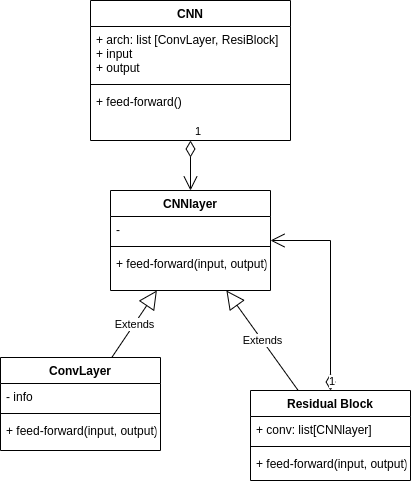

## Main implementation CPU

### Back functions

Functions included:
- trunc(): truncate value into a certain range.
- conv2d_cpu(): 2d convolution on CPU.
- mean_cpu(): mean of 2d image on CPU.
- var_cpu(): variance of 2d image on CPU.
- bn_cpu(): batch normalization of 2d images in a 4d image block on CPU, uses mean_cpu() and var_cpu()
- leakyrelu_cpu(): LeakyReLU of 4d image block on CPU.
- conv_layer_cpu(): convolutional layer on CPU, uses conv2d_cpu(), bn_cpu(), leakyrelu_cpu().
- fixed_avg_pool_cpu(): average pooling of 2d images with fixed input sizes to 1x1, on CPU.
- flatten2d_cpu(): flattening of 2d image to 1d, on CPU.
- linear_cpu(): linearly connected layer on CPU

In [ ]:
%%writefile backfunctions.py
from numba import jit, prange
import math
import numpy as np

@jit
def trunc(val, min, max):
  if val < min:
    return min
  elif val > max:
    return max
  else:
    return val

@jit
def conv2d_cpu(input, kernel, bias, output, stride=1, padding=1, dilation=1):
  # calculate
  output_shape = (input.shape[0], kernel.shape[0],
                  math.floor((input.shape[2] - (kernel.shape[1] - 1) * dilation + 2*padding - 1) / stride) + 1,
                  math.floor((input.shape[3] - (kernel.shape[2] - 1) * dilation + 2*padding - 1) / stride) + 1)

  for im in range(output_shape[0]):
    for c_out in range(output_shape[1]):
      for x in range(output_shape[2]):
        for y in range(output_shape[3]):
          sum = 0
          for x_k in range(kernel.shape[1]):
            for y_k in range(kernel.shape[2]):
              x_in = x * stride + x_k * dilation - padding
              y_in = y * stride + y_k * dilation - padding
              x_in = trunc(x_in, 0, input.shape[2] - 1)
              y_in = trunc(y_in, 0, input.shape[3] - 1)

              sum += np.sum(input[im, :, x_in, y_in]) * kernel[c_out, x_k, y_k]
          output[im, c_out, x, y] = sum + bias[c_out]

@jit
def mean_cpu(image2d):
  sum = 0
  for y in range(image2d.shape[1]):
    for x in range(image2d.shape[0]):
      sum += image2d[x,y]
  return sum / image2d.shape[0] / image2d.shape[1]

@jit
def var_cpu(image2d):
  Mean = mean_cpu(image2d)
  L2sum = 0

  for y in range(image2d.shape[1]):
    for x in range(image2d.shape[0]):
      L2sum += (image2d[x,y] - Mean) ** 2
  return L2sum / image2d.shape[0] / image2d.shape[1]

@jit
def bn_cpu(image_tensor, stab=1e-5):
  channels = image_tensor.shape[1]
  for k in range(image_tensor.shape[0]):
    for c in range(image_tensor.shape[1]):
      Mean = mean_cpu(image_tensor[k,c])
      Var = var_cpu(image_tensor[k,c])

      image_tensor[k,c] = (image_tensor[k,c] - Mean) / np.sqrt(Var + stab)

@jit
def leakyrelu_cpu(image_arr, alpha=0.01):
  for i in range(image_arr.shape[0]):
    for j in range(image_arr.shape[1]):
      for k in range(image_arr.shape[2]):
        for l in range(image_arr.shape[3]):
          if image_arr[i,j,k,l] <= 0:
            image_arr[i,j,k,l] *= alpha

@jit
def conv_layer_cpu(image_arr, kernel, bias, output, stride=1, padding=0, dil=1):
  # convolution
  conv2d_cpu(input, kernel, bias, output, stride, padding, dilation)

  # batch norm
  bn_cpu(output)

  # leaky ReLU
  leakyrelu_cpu(output)

@jit
def fixed_avg_pool_cpu(input, output):
  if output.shape != input.shape[:2]:
    raise ValueError("Unmatched output shape")

  feature_map_size = input.shape[2] * input.shape[3]
  for i in range(output.shape[0]):
    for j in range(output.shape[1]):
      sum = 0
      for k in range(input.shape[2]):
        for l in range(input.shape[3]):
          sum += input[i,j,k,l]
      output[i,j] = sum / feature_map_size

@jit
def flatten2d_cpu(input, output):
  output_shape = input.shape[0] * input.shape[1]
  for i in prange(input.shape[0]):
    for j in prange(input.shape[1]):
      output[i * input.shape[1] + j] = input[i,j]

@jit
def linear_cpu(input, weights, bias, output):
  # basically it's a multiplication of a matrix sized (1 x W)
  # with weights (W x H) + bias (1 x H) to output (1 x H)

  for i in range(output.shape[0]):
    sum = 0
    for j in range(input.shape[0]):
      sum += input[j] * weights[j,i]
    output[i] = sum + bias[i]

Overwriting backfunctions.py


In [ ]:
%reload_ext autoreload
%autoreload 2

### Layer classes

In [ ]:
import backfunctions as BF
import math
import numpy as np

class CNNLayer:
  def __init__(self):
    pass

  def forward(self, input):
    pass

class Conv2DLayer(CNNLayer):
  def __init__(self, in_channels, out_channels, kernel_size, stride, padding, dilation):
    self.in_channels = in_channels
    self.out_channels = out_channels
    self.kernel_size = kernel_size
    self.stride = stride
    self.padding = padding
    self.dilation = dilation

    self.kernel = np.random.randn(out_channels, kernel_size, kernel_size)
    self.bias = np.random.randn(out_channels)

  def forward(self, input):
    # setups
    nsamples, c_in, h_in, w_in = input.shape
    if c_in != self.in_channels:
      raise ValueError("Unmatched input channels")

    output_shape = (nsamples, self.out_channels,
                  math.floor((input.shape[2] - (self.kernel_size - 1) * self.dilation + 2*self.padding - 1) / self.stride) + 1,
                  math.floor((input.shape[3] - (self.kernel_size - 1) * self.dilation + 2*self.padding - 1) / self.stride) + 1)
    output = np.zeros(output_shape, dtype=np.float32)

    # execute
    BF.conv2d_cpu(input, self.kernel, self.bias, output, self.stride, self.padding, self.dilation)
    BF.bn_cpu(output)
    BF.leakyrelu_cpu(output)

    return output

class ResidualBlock(CNNLayer):
  def __init__(self, in_channels):
    self.in_channels = in_channels
    self.mid_channels = in_channels // 2
    self.conv1 = Conv2DLayer(in_channels, self.mid_channels, 1, 1, 0, 1)
    self.conv2 = Conv2DLayer(self.mid_channels, self.in_channels, 3, 1, 1, 1)

  def forward(self, input):
    # setups
    output1_shape = (input.shape[0], self.mid_channels, input.shape[2], input.shape[3])
    output1 = np.zeros(output1_shape, dtype=np.float32)
    output2 = np.zeros(input.shape, dtype=np.float32)

    # execute
    output1 = self.conv1.forward(input)
    BF.bn_cpu(output1)
    output2 = self.conv2.forward(output1)
    BF.bn_cpu(output2)
    output2 = output2 + input
    BF.leakyrelu_cpu(output2)

    return output2

class FixedAvgPool(CNNLayer):
  def __init__(self, in_channels):
    self.in_channels = in_channels

  def forward(self, input):
    # setups
    if input.shape[1] != self.in_channels:
      raise ValueError("Unmatched input channels, check code again")

    output_shape = input.shape[:2]
    output = np.zeros(output_shape, dtype=np.float32)

    # execute
    BF.fixed_avg_pool_cpu(input, output)

    return output

class Flatten2D(CNNLayer):
  def __init__(self):
    pass

  def forward(self, input):
    # setups
    if len(input.shape) > 2:
      raise ValueError("Unsupported input shape")
    if len(input.shape) == 1:
      return

    output = np.zeros(input.shape[0] * input.shape[1])

    # execute
    BF.flatten2d_cpu(input, output)

    return output

class Linear(CNNLayer):
  def __init__(self, in_features, out_features):
    self.in_features = in_features
    self.out_features = out_features
    self.weights = np.random.randn(in_features, out_features)
    self.bias = np.random.randn(out_features)

  def forward(self, input):
    # setups
    output = np.zeros((self.out_features), dtype=np.float32)

    # execute
    BF.linear_cpu(input, self.weights, self.bias, output)

    return output

class CNN:
  def __init__(self, layers = None):
    if layers is None:
      self.layers = []
    elif isinstance(layers, CNNLayer):
      self.layers = [layers]
    elif isinstance(layers, list) and (len(layers) == 0 or isinstance(layers[0], CNNLayer)):
      self.layers = layers
    else:
      raise TypeError("Unsupported layer type")

  def add(self, layer):
    if isinstance(layer, CNNLayer):
      self.layers.append(layer)
    elif isinstance(layer, list) and (len(layer) == 0 or isinstance(layer[0], CNNLayer)):
      self.layers.extend(layer)
    else:
      raise TypeError("Unsupported layer type")

  def forward(self, input):
    output = input
    for i in range(len(self.layers)):
      print(f"Layer {i}")
      output = self.layers[i].forward(output)
      print(output.shape)
    return output

### Test

In [ ]:
darknet53 = CNN([
    Conv2DLayer(3, 32, 3, 1, 1, 1),
    Conv2DLayer(32, 64, 3, 2, 1, 1),
    ResidualBlock(64),
    Conv2DLayer(64, 128, 3, 2, 1, 1),
    ResidualBlock(128),
    ResidualBlock(128),
    Conv2DLayer(128, 256, 3, 2, 1, 1),
    ResidualBlock(256),
    ResidualBlock(256),
    ResidualBlock(256),
    ResidualBlock(256),
    ResidualBlock(256),
    ResidualBlock(256),
    ResidualBlock(256),
    ResidualBlock(256),
    Conv2DLayer(256, 512, 3, 2, 1, 1),
    ResidualBlock(512),
    ResidualBlock(512),
    ResidualBlock(512),
    ResidualBlock(512),
    ResidualBlock(512),
    ResidualBlock(512),
    ResidualBlock(512),
    ResidualBlock(512),
    Conv2DLayer(512, 1024, 3, 2, 1, 1),
    ResidualBlock(1024),
    ResidualBlock(1024),
    ResidualBlock(1024),
    ResidualBlock(1024),
    FixedAvgPool(1024),
    Flatten2D(),
    Linear(1024, 10)
])

output = darknet53.forward(np.random.randn(1, 3, 416, 416).astype('float32'))
print(output.shape)

Layer 0
(1, 32, 416, 416)
Layer 1
(1, 64, 208, 208)
Layer 2
(1, 64, 208, 208)
Layer 3
(1, 128, 104, 104)
Layer 4
(1, 128, 104, 104)
Layer 5
(1, 128, 104, 104)
Layer 6
(1, 256, 52, 52)
Layer 7
(1, 256, 52, 52)
Layer 8
(1, 256, 52, 52)
Layer 9
(1, 256, 52, 52)
Layer 10
(1, 256, 52, 52)
Layer 11
(1, 256, 52, 52)
Layer 12
(1, 256, 52, 52)
Layer 13
(1, 256, 52, 52)
Layer 14
(1, 256, 52, 52)
Layer 15
(1, 512, 26, 26)
Layer 16
(1, 512, 26, 26)
Layer 17
(1, 512, 26, 26)
Layer 18
(1, 512, 26, 26)
Layer 19
(1, 512, 26, 26)
Layer 20
(1, 512, 26, 26)
Layer 21
(1, 512, 26, 26)
Layer 22
(1, 512, 26, 26)
Layer 23
(1, 512, 26, 26)
Layer 24
(1, 1024, 13, 13)
Layer 25
(1, 1024, 13, 13)
Layer 26
(1, 1024, 13, 13)
Layer 27
(1, 1024, 13, 13)
Layer 28
(1, 1024, 13, 13)
Layer 29
(1, 1024)
Layer 30
(1024,)
Layer 31
(10,)
(10,)


# Implementation: CSP-enhanced Darknet53